# 12 — Bellman Expectation & Optimality Equations
*How value functions relate to rewards, transitions, and optimal control.*

**What you'll learn**

- Bellman expectation equations for $ v^\pi $ and $ q^\pi $  
- Bellman operators $T^\pi$ and their contraction property  
- Bellman optimality equations for $ v^* $ and $ q^* $  
- How to solve small MDPs via linear systems and iterative updates  
- How these equations are the backbone of Dynamic Programming, Monte Carlo, and TD

> The Bellman equations are the “physics laws” of RL value functions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## 1. Bellman Expectation Equation — State-Value

For a fixed policy $ \pi $, the state-value function is

$$
v^\pi(s) = \mathbb{E}_\pi \big[ G_t \mid S_t = s \big],
\quad
G_t = \sum_{k=0}^\infty \gamma^k R_{t+k+1}.
$$

Using the Markov property and unrolling one step:

$$
\begin{aligned}
v^\pi(s)
&= \mathbb{E}_\pi \big[ R_{t+1} + \gamma G_{t+1} \mid S_t = s \big] \\
&= \mathbb{E}_\pi \big[ R_{t+1} + \gamma v^\pi(S_{t+1}) \mid S_t = s \big].
\end{aligned}
$$

In terms of the MDP dynamics:

$$
v^\pi(s)
= \sum_a \pi(a \mid s)
   \sum_{s', r} p(s', r \mid s, a)\,\big( r + \gamma v^\pi(s') \big).
$$

For finite state spaces, we can write this in vector form:

$$
v^\pi = r^\pi + \gamma P^\pi v^\pi,
$$

where:
- $ v^\pi \in \mathbb{R}^{|\mathcal{S}|} $ is the value vector  
- $ r^\pi \in \mathbb{R}^{|\mathcal{S}|} $ with $ r^\pi(s) = \mathbb{E}[R_{t+1} \mid S_t=s, \pi] $  
- $ P^\pi $ is the transition matrix induced by policy $ \pi $

So,

$$
(\mathbf{I} - \gamma P^\pi) v^\pi = r^\pi
\quad \Rightarrow \quad
v^\pi = (\mathbf{I} - \gamma P^\pi)^{-1} r^\pi,
$$

for small MDPs where matrix inversion is practical.

In [2]:
# Tiny 3-state MDP: s0, s1, terminal s2
STATE_NAMES = {0: "s0", 1: "s1", 2: "terminal"}
ACTION_NAMES = {0: "Left", 1: "Right"}

gamma = 0.9

# Transition model P(s' | s, a) with fixed rewards r(s,a,s')
P_env = {
    (0, 0): [(1.0, 0, 0.0)],   # s0, Left  -> s0, r=0
    (0, 1): [(1.0, 1, +1.0)],  # s0, Right -> s1, r=+1
    (1, 0): [(1.0, 0, +0.5)],  # s1, Left  -> s0, r=+0.5
    (1, 1): [(1.0, 2, +2.0)],  # s1, Right -> s2, r=+2
    # terminal is absorbing
    (2, 0): [(1.0, 2, 0.0)],
    (2, 1): [(1.0, 2, 0.0)],
}

num_states = 3
num_actions = 2

# Deterministic policy π: always take Right (1) in s0,s1
policy_right = {0: 1, 1: 1, 2: 0}  # action in each state

def build_P_pi_and_r_pi(policy):
    P_pi = np.zeros((num_states, num_states))
    r_pi = np.zeros(num_states)
    for s in range(num_states):
        for a in range(num_actions):
            pi_sa = 1.0 if policy[s] == a else 0.0
            for p, s_next, r in P_env[(s, a)]:
                P_pi[s, s_next] += pi_sa * p
                r_pi[s] += pi_sa * p * r
    return P_pi, r_pi

P_pi, r_pi = build_P_pi_and_r_pi(policy_right)

print("P^π (policy 'go Right'):\n", P_pi)
print("\nr^π:\n", r_pi)

P^π (policy 'go Right'):
 [[0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]

r^π:
 [1. 2. 0.]


In [3]:
# Treat state 2 as terminal with v(terminal) defined by the equation as well.
# Here, it's an absorbing state with zero reward onward, so the Bellman equation still holds.

I = np.eye(num_states)
v_pi_closed = np.linalg.solve(I - gamma * P_pi, r_pi)

print("Closed-form v^π (go Right):", np.round(v_pi_closed, 3))

Closed-form v^π (go Right): [2.8 2.  0. ]


## 2. Bellman Operator & Iterative Policy Evaluation

Define the Bellman expectation operator for policy $ \pi $:

$$
(T^\pi v)(s)
= \mathbb{E}_\pi \big[ R_{t+1} + \gamma v(S_{t+1}) \mid S_t = s \big].
$$

In vector form:

$$
T^\pi v = r^\pi + \gamma P^\pi v.
$$

The Bellman expectation equation says:

$$
v^\pi = T^\pi v^\pi.
$$

For $ \gamma \in [0,1) $, $ T^\pi $ is a contraction mapping under the max-norm:

$$
\| T^\pi v - T^\pi w \|_\infty \le \gamma \| v - w \|_\infty,
$$

which guarantees that repeated application converges:

$$
v_{k+1} = T^\pi v_k \quad \Rightarrow \quad v_k \to v^\pi.
$$

This “fixed point iteration” is the core of Dynamic Programming (Policy Evaluation) and is conceptually similar to TD learning.

In [4]:
def bellman_T_pi(v, r_pi, P_pi, gamma):
    """Apply Bellman expectation operator T^π to value vector v."""
    return r_pi + gamma * (P_pi @ v)

def iterative_policy_evaluation(r_pi, P_pi, gamma, num_iters=30, v_init=None):
    if v_init is None:
        v = np.zeros(P_pi.shape[0])
    else:
        v = v_init.copy()
    history = [v.copy()]
    for _ in range(num_iters):
        v = bellman_T_pi(v, r_pi, P_pi, gamma)
        history.append(v.copy())
    return np.array(history)

v_hist = iterative_policy_evaluation(r_pi, P_pi, gamma, num_iters=25)
print("Last iterate v_25:", np.round(v_hist[-1], 3))
print("Closed-form v^π  :", np.round(v_pi_closed, 3))

Last iterate v_25: [2.8 2.  0. ]
Closed-form v^π  : [2.8 2.  0. ]


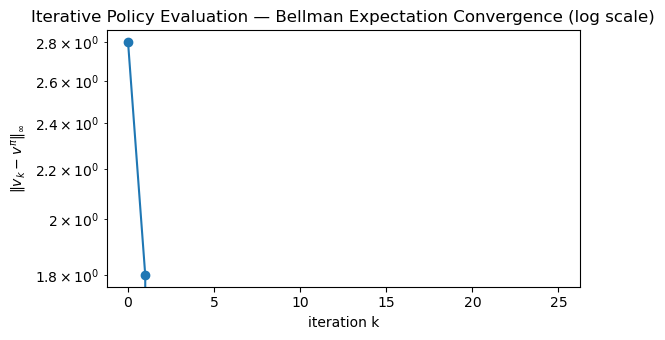

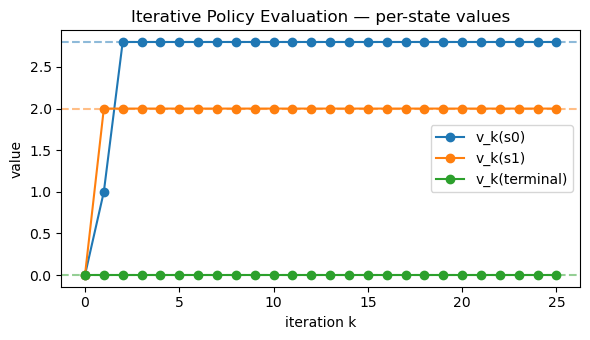

In [5]:
iters = np.arange(v_hist.shape[0])
errors = np.linalg.norm(v_hist - v_pi_closed, ord=np.inf, axis=1)

plt.figure(figsize=(6,3.5))
plt.plot(iters, errors, marker="o")
plt.yscale("log")
plt.xlabel("iteration k")
plt.ylabel(r"$\|v_k - v^\pi\|_\infty$")
plt.title("Iterative Policy Evaluation — Bellman Expectation Convergence (log scale)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,3.5))
for s in range(num_states):
    plt.plot(iters, v_hist[:, s], marker="o", label=f"v_k({STATE_NAMES[s]})")
plt.axhline(v_pi_closed[0], color="C0", linestyle="--", alpha=0.5)
plt.axhline(v_pi_closed[1], color="C1", linestyle="--", alpha=0.5)
plt.axhline(v_pi_closed[2], color="C2", linestyle="--", alpha=0.5)
plt.xlabel("iteration k")
plt.ylabel("value")
plt.title("Iterative Policy Evaluation — per-state values")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Bellman Expectation Equation — Action-Value

The action-value function under policy $ \pi $:

$$
q^\pi(s,a) = \mathbb{E}_\pi \big[ G_t \mid S_t = s, A_t = a \big].
$$

Bellman expectation equation:

$$
q^\pi(s,a)
= \sum_{s',r} p(s', r \mid s,a)\,\Big( r + \gamma \sum_{a'} \pi(a' \mid s') q^\pi(s',a') \Big).
$$

Relationship between $ v^\pi $ and $ q^\pi $:

$$
v^\pi(s) = \sum_a \pi(a \mid s)\,q^\pi(s,a).
$$

Later, algorithms like SARSA and Expected SARSA will be directly implementing these relationships in sample-based form.

## 4. Bellman Optimality — Searching for the Best Policy

We define the optimal value functions:

- **Optimal state-value**:
  $$
  v^*(s) = \max_\pi v^\pi(s).
  $$

- **Optimal action-value**:
  $$
  q^*(s,a) = \max_\pi q^\pi(s,a).
  $$

These satisfy the Bellman optimality equations:

$$
v^*(s) = \max_a \sum_{s',r} p(s', r \mid s,a)\,\big( r + \gamma v^*(s') \big),
$$

$$
q^*(s,a) = \sum_{s',r} p(s', r \mid s,a)\,\big( r + \gamma \max_{a'} q^*(s', a') \big).
$$

Given $ v^* $, we can extract a greedy optimal policy:

$$
\pi^*(s) \in \arg\max_a \sum_{s',r} p(s',r \mid s,a)\,\big( r + \gamma v^*(s') \big).
$$

These equations are at the heart of:

- **Dynamic Programming**: Policy Iteration & Value Iteration  
- **Value-Based RL**: Q-Learning, DQN, etc.

In this notebook, we’ll solve $ v^* $ and $ \pi^* $ for our tiny MDP by directly applying the optimality operator.

In [6]:
def bellman_optimality_operator(v, gamma):
    """(T v)(s) = max_a E[r + γ v(s')] over actions."""
    v_new = np.zeros_like(v)
    for s in range(num_states):
        # Evaluate each action's expected return
        q_vals = []
        for a in range(num_actions):
            total = 0.0
            for p, s_next, r in P_env[(s, a)]:
                total += p * (r + gamma * v[s_next])
            q_vals.append(total)
        v_new[s] = max(q_vals)
    return v_new

def value_iteration(gamma, num_iters=50):
    v = np.zeros(num_states)
    history = [v.copy()]
    for _ in range(num_iters):
        v = bellman_optimality_operator(v, gamma)
        history.append(v.copy())
    return np.array(history)

v_opt_hist = value_iteration(gamma, num_iters=25)
v_star = v_opt_hist[-1]

print("Approx optimal v*:", np.round(v_star, 3))

Approx optimal v*: [7.156 6.94  0.   ]


In [7]:
def greedy_policy_from_v(v, gamma):
    """Compute greedy policy w.r.t. given value function."""
    policy = {}
    for s in range(num_states):
        q_vals = []
        for a in range(num_actions):
            total = 0.0
            for p, s_next, r in P_env[(s, a)]:
                total += p * (r + gamma * v[s_next])
            q_vals.append(total)
        best_a = int(np.argmax(q_vals))
        policy[s] = best_a
    return policy

pi_star = greedy_policy_from_v(v_star, gamma)

print("Greedy policy π* (indices):", pi_star)
print("Greedy policy π* (named):", {STATE_NAMES[s]: ACTION_NAMES[a] for s, a in pi_star.items()})

Greedy policy π* (indices): {0: 1, 1: 0, 2: 0}
Greedy policy π* (named): {'s0': 'Right', 's1': 'Left', 'terminal': 'Left'}


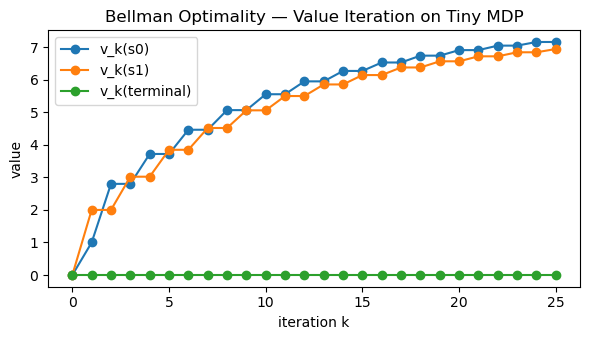

In [8]:
iters_opt = np.arange(v_opt_hist.shape[0])

plt.figure(figsize=(6,3.5))
for s in range(num_states):
    plt.plot(iters_opt, v_opt_hist[:, s], marker="o", label=f"v_k({STATE_NAMES[s]})")
plt.xlabel("iteration k")
plt.ylabel("value")
plt.title("Bellman Optimality — Value Iteration on Tiny MDP")
plt.legend()
plt.tight_layout()
plt.show()

## Key Takeaways

- Bellman expectation equations relate $ v^\pi $ to immediate rewards and the next-state values:
  $$
  v^\pi = r^\pi + \gamma P^\pi v^\pi.
  $$
- The Bellman operator $T^\pi$ is a contraction, so iterating
  $
  v_{k+1} = T^\pi v_k
  $
  converges to $ v^\pi $.  
- Bellman optimality equations define $ v^*, q^* $ via a max over actions and form the basis of control:
  $$
  v^*(s) = \max_a \mathbb{E}[R_{t+1} + \gamma v^*(S_{t+1}) \mid s,a ].
  $$
- Small MDPs can be solved exactly via linear systems (policy evaluation) or via value iteration (control).  
- Dynamic Programming, Monte Carlo, and Temporal-Difference methods are all different ways to approximate these fixed points in increasingly realistic settings.

**Next:** `13_dp_policy_evaluation.ipynb` → formalizing iterative policy evaluation and connecting it to Monte Carlo & TD.